In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from src.features.feature import clean_sales_data 
import pandas as pd 

In [3]:
raw_df = pd.read_excel('../data/forecasting-study.xlsx')
clean_df = clean_sales_data(raw_df)
print(clean_df.shape)
print(clean_df.isna().sum())

(9718, 13)
Date               0
Total              0
Total_log          0
State              0
Category           0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_4     0
rolling_std_4      0
is_holiday_week    0
month              0
week_of_year       0
dtype: int64


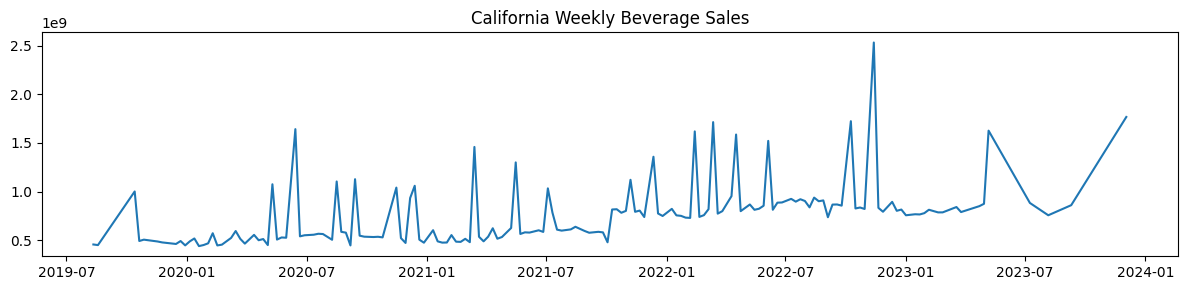

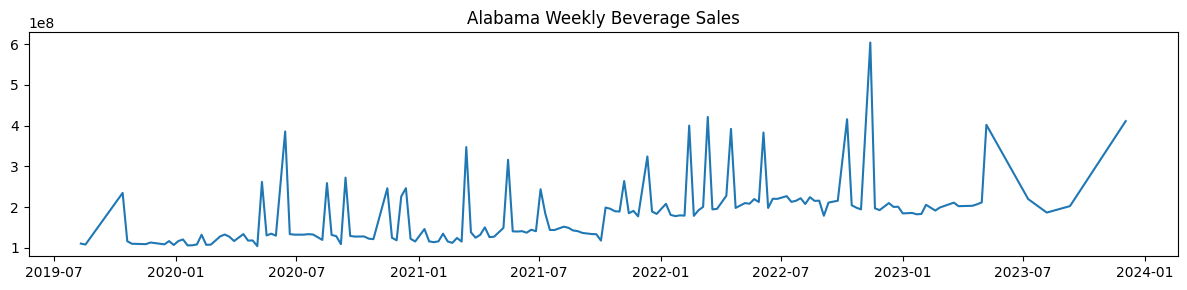

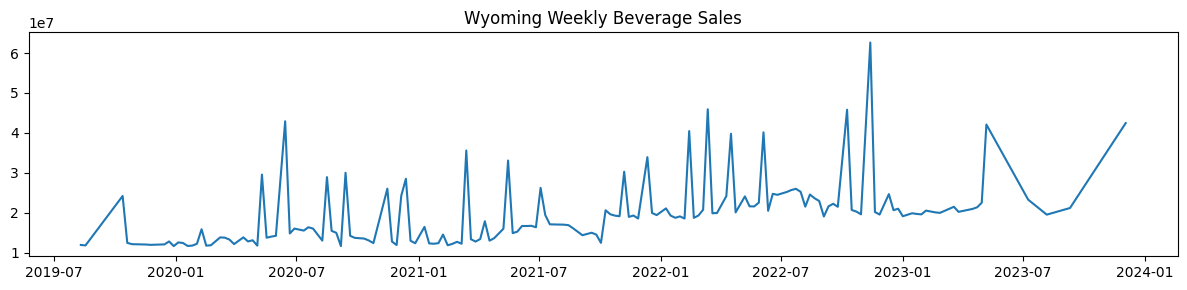

In [ ]:
import matplotlib.pyplot as plt

for state in ['California', 'Alabama', 'Wyoming']:
    state_data = clean_df[clean_df['State'] == state]
    plt.figure(figsize=(12, 3))
    plt.plot(state_data['Date'], state_data['Total'])
    plt.title(f'{state} Weekly Beverage Sales')
    plt.tight_layout()
    plt.show()

In [5]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [6]:
from src.models.xgboost_model import train_global_xgboost
import xgboost as xgb

xgb_model, scoreboard = train_global_xgboost(clean_df)


Running without local baselines.
Training xgboost on 9374 rows

Top 10 Important features 
rolling_mean_4: 0.8909000158309937
lag_30: 0.04309999942779541
lag_1: 0.02160000056028366
week_of_year: 0.0066999997943639755
rolling_std_4: 0.006099999882280827
month: 0.005900000222027302
is_holiday_week: 0.00559999980032444
lag_7: 0.0017000000225380063
State_Vermont: 0.0017000000225380063
State_Colorado: 0.0013000000035390258

 Behavioral feature
rolling_mean_4: 0.8909000158309937




Prediction range:
Min: 1.8414888e+07
Max: 1.318358e+09
First 5 predictions: [2.4362949e+08 2.6487277e+08 3.0242093e+08 4.1504554e+08 3.1748560e+08]
Min: 1.8414888e+07
Training done


In [28]:
xgb_model.save_model("models/global_xgboost.json")

In [7]:
print(scoreboard)

{'Alabama': {'XGBoost_SMAPE': np.float64(15.41), 'Current_Best': 'XGBoost'}, 'Arizona': {'XGBoost_SMAPE': np.float64(15.32), 'Current_Best': 'XGBoost'}, 'Arkansas': {'XGBoost_SMAPE': np.float64(11.72), 'Current_Best': 'XGBoost'}, 'California': {'XGBoost_SMAPE': np.float64(32.77), 'Current_Best': 'XGBoost'}, 'Colorado': {'XGBoost_SMAPE': np.float64(14.26), 'Current_Best': 'XGBoost'}, 'Connecticut': {'XGBoost_SMAPE': np.float64(13.56), 'Current_Best': 'XGBoost'}, 'Florida': {'XGBoost_SMAPE': np.float64(27.47), 'Current_Best': 'XGBoost'}, 'Georgia': {'XGBoost_SMAPE': np.float64(19.36), 'Current_Best': 'XGBoost'}, 'Illinois': {'XGBoost_SMAPE': np.float64(23.86), 'Current_Best': 'XGBoost'}, 'Indiana': {'XGBoost_SMAPE': np.float64(15.41), 'Current_Best': 'XGBoost'}, 'Iowa': {'XGBoost_SMAPE': np.float64(12.25), 'Current_Best': 'XGBoost'}, 'Kansas': {'XGBoost_SMAPE': np.float64(12.95), 'Current_Best': 'XGBoost'}, 'Kentucky': {'XGBoost_SMAPE': np.float64(11.36), 'Current_Best': 'XGBoost'}, 'Lou

In [8]:
from src.models.prophet_model import train_local_prophet

prophet_models,scoreboard = train_local_prophet(clean_df)

Importing plotly failed. Interactive plots will not work.
11:30:52 - cmdstanpy - INFO - Chain [1] start processing
11:30:52 - cmdstanpy - INFO - Chain [1] done processing
11:30:53 - cmdstanpy - INFO - Chain [1] start processing
11:30:53 - cmdstanpy - INFO - Chain [1] done processing


Alabama : Prophet smape = 17.83
Arizona : Prophet smape = 20.31


11:30:53 - cmdstanpy - INFO - Chain [1] start processing
11:30:53 - cmdstanpy - INFO - Chain [1] done processing
11:30:53 - cmdstanpy - INFO - Chain [1] start processing
11:30:53 - cmdstanpy - INFO - Chain [1] done processing


Arkansas : Prophet smape = 18.68
California : Prophet smape = 20.34


11:30:53 - cmdstanpy - INFO - Chain [1] start processing
11:30:53 - cmdstanpy - INFO - Chain [1] done processing
11:30:53 - cmdstanpy - INFO - Chain [1] start processing
11:30:53 - cmdstanpy - INFO - Chain [1] done processing


...

Virginia : Prophet smape = 19.59
Washington : Prophet smape = 19.86


11:30:59 - cmdstanpy - INFO - Chain [1] start processing
11:30:59 - cmdstanpy - INFO - Chain [1] done processing
11:30:59 - cmdstanpy - INFO - Chain [1] start processing
11:30:59 - cmdstanpy - INFO - Chain [1] done processing


West Virginia : Prophet smape = 21.27


11:30:59 - cmdstanpy - INFO - Chain [1] start processing
11:30:59 - cmdstanpy - INFO - Chain [1] done processing


Wisconsin : Prophet smape = 19.17
Wyoming : Prophet smape = 19.4
Done training


In [27]:
import joblib 
joblib.dump(prophet_models, "models/prophet_models.pkl")

['models/prophet_models.pkl']

In [9]:
print(scoreboard)

{'Alabama': {'XGBoost_SMAPE': 15.41, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': np.float64(17.83)}, 'Arizona': {'XGBoost_SMAPE': 15.32, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': np.float64(20.31)}, 'Arkansas': {'XGBoost_SMAPE': 11.72, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': np.float64(18.68)}, 'California': {'XGBoost_SMAPE': 32.77, 'Current_Best': 'Prophet', 'Prophet_SMAPE': np.float64(20.34)}, 'Colorado': {'XGBoost_SMAPE': 14.26, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': np.float64(20.03)}, 'Connecticut': {'XGBoost_SMAPE': 13.56, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': np.float64(19.4)}, 'Florida': {'XGBoost_SMAPE': 27.47, 'Current_Best': 'Prophet', 'Prophet_SMAPE': np.float64(21.62)}, 'Georgia': {'XGBoost_SMAPE': 19.36, 'Current_Best': 'Prophet', 'Prophet_SMAPE': np.float64(17.77)}, 'Illinois': {'XGBoost_SMAPE': 23.86, 'Current_Best': 'Prophet', 'Prophet_SMAPE': np.float64(21.73)}, 'Indiana': {'XGBoost_SMAPE': 15.41, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': np.float64

In [10]:
sample_state = clean_df[clean_df['State'] == 'Alabama'].sort_values('Date')
cutoff = sample_state['Date'].max() - pd.Timedelta(weeks=8)
val = sample_state[sample_state['Date'] > cutoff]
print(val[['Date', 'Total', 'is_holiday_week']])

          Date         Total  is_holiday_week
218 2023-10-15  2.892456e+08                1
219 2023-10-22  3.066256e+08                0
220 2023-10-29  3.240056e+08                0
221 2023-11-05  3.413856e+08                0
222 2023-11-12  3.587656e+08                1
223 2023-11-19  3.761455e+08                0
224 2023-11-26  3.935255e+08                1
225 2023-12-03  4.109055e+08                0


In [25]:
from src.models.arima_model import train_local_arima 

arima_models,scoreboard = train_local_arima(clean_df)

Alabama : ARIMA SMAPE score 37.04 and the Winner : XGBoost
Arizona : ARIMA SMAPE score 30.48 and the Winner : XGBoost
Arkansas : ARIMA SMAPE score 36.83 and the Winner : XGBoost
California : ARIMA SMAPE score 40.1 and the Winner : Prophet
Colorado : ARIMA SMAPE score 38.34 and the Winner : XGBoost
Connecticut : ARIMA SMAPE score 36.45 and the Winner : XGBoost
Florida : ARIMA SMAPE score 39.51 and the Winner : Prophet
Georgia : ARIMA SMAPE score 37.47 and the Winner : Prophet
Illinois : ARIMA SMAPE score 39.1 and the Winner : Prophet
Indiana : ARIMA SMAPE score 37.54 and the Winner : XGBoost
Iowa : ARIMA SMAPE score 36.59 and the Winner : XGBoost
Kansas : ARIMA SMAPE score 36.53 and the Winner : XGBoost
Kentucky : ARIMA SMAPE score 36.89 and the Winner : XGBoost
Louisiana : ARIMA SMAPE score 38.65 and the Winner : XGBoost
Maine : ARIMA SMAPE score 39.08 and the Winner : XGBoost
Maryland : ARIMA SMAPE score 38.47 and the Winner : XGBoost
Massachusetts : ARIMA SMAPE score 37.97 and the Wi

In [26]:
import joblib 
joblib.dump(arima_models, "models/arima_models.pkl")

['models/arima_models.pkl']

In [20]:
import sys
sys.path.append('..')
from src.models.lstm_model import train_global_lstm

lstm_models,scoreboard = train_global_lstm(clean_df)

Epoch 1/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 88.9422 - val_loss: 0.2258
Epoch 2/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1817 - val_loss: 0.1049
Epoch 3/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1184 - val_loss: 0.0994
Epoch 4/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1006 - val_loss: 0.0995
Epoch 5/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0922 - val_loss: 0.0987
Epoch 6/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0869 - val_loss: 0.0936
Epoch 7/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0830 - val_loss: 0.0891
Epoch 8/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0804 - val_loss: 0.0850
Epoch 9/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0785 - val_loss: 0.0806
Epoch 10/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0770 - val_loss: 0.0760
Epoch 11/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0757 - val_loss: 0.0728
Epoch 12/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

In [18]:
print(scoreboard)

{'Alabama': {'XGBoost_SMAPE': 15.41, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': 17.83, 'ARIMA_SMAPE': 37.04, 'LSTM_SMAPE': np.float64(37.07)}, 'Arizona': {'XGBoost_SMAPE': 15.32, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': 20.31, 'ARIMA_SMAPE': 30.48, 'LSTM_SMAPE': np.float64(38.56)}, 'Arkansas': {'XGBoost_SMAPE': 11.72, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': 18.68, 'ARIMA_SMAPE': 36.83, 'LSTM_SMAPE': np.float64(34.75)}, 'California': {'XGBoost_SMAPE': 32.77, 'Current_Best': 'Prophet', 'Prophet_SMAPE': 20.34, 'ARIMA_SMAPE': 40.1, 'LSTM_SMAPE': np.float64(52.76)}, 'Colorado': {'XGBoost_SMAPE': 14.26, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': 20.03, 'ARIMA_SMAPE': 38.34, 'LSTM_SMAPE': np.float64(38.12)}, 'Connecticut': {'XGBoost_SMAPE': 13.56, 'Current_Best': 'XGBoost', 'Prophet_SMAPE': 19.4, 'ARIMA_SMAPE': 36.45, 'LSTM_SMAPE': np.float64(32.91)}, 'Florida': {'XGBoost_SMAPE': 27.47, 'Current_Best': 'Prophet', 'Prophet_SMAPE': 21.62, 'ARIMA_SMAPE': 39.51, 'LSTM_SMAPE': np.float64(

In [12]:
import sys
sys.path.append('..')
from src.models.forecast import generate_all_forecasts
import json 
import xgboost as xgb 
from tensorflow.keras.models import load_model
import joblib

with open('xgb_feature_columns.json','r') as f:
    feature_columns = json.load(f)

xgb_model = xgb.XGBRegressor()
xgb_model.load_model("models/global_xgboost.json")

prophet_models = joblib.load("models/prophet_models.pkl")
arima_models = joblib.load("models/arima_models.pkl")    
lstm_model = load_model("models/global_lstm.keras")
    
forecasts = generate_all_forecasts(
    clean_df,
    xgb_model,
    prophet_models,
    arima_models,
    feature_columns
)

print(forecasts['California'])
print(forecasts['Alabama'])

Alabama (XGBoost) : [405.9, 379.3, 368.1, 359.1, 372.2, 367.5, 363.0, 371.0] M
Arizona (XGBoost) : [434.0, 417.7, 391.7, 395.9, 412.4, 397.1, 373.9, 368.1] M
Arkansas (XGBoost) : [214.0, 201.2, 204.5, 195.0, 207.2, 200.3, 195.1, 208.1] M
California (Prophet) : [1076.5, 1042.2, 1203.8, 1429.7, 1525.0, 1370.8, 1154.2, 1020.0] M
Colorado (XGBoost) : [353.9, 338.7, 348.9, 342.3, 365.7, 327.0, 309.7, 303.8] M
Connecticut (XGBoost) : [174.6, 167.1, 175.0, 174.3, 181.0, 187.6, 178.1, 180.3] M
Florida (Prophet) : [944.4, 887.7, 1020.1, 1222.2, 1329.4, 1182.5, 992.8, 848.3] M
Georgia (Prophet) : [479.8, 463.3, 526.7, 622.2, 666.1, 609.5, 516.6, 458.0] M
Illinois (Prophet) : [390.5, 372.4, 428.2, 515.0, 556.6, 507.4, 428.0, 380.9] M
Indiana (XGBoost) : [470.0, 427.5, 402.4, 405.5, 396.3, 396.8, 377.1, 369.5] M
Iowa (XGBoost) : [218.0, 214.4, 215.7, 209.5, 208.6, 199.9, 201.9, 208.5] M
Kansas (XGBoost) : [176.8, 168.7, 174.9, 173.7, 181.7, 187.9, 179.9, 173.1] M
Kentucky (XGBoost) : [343.5, 323.4